In [1]:
import requests
import zipfile
from pathlib import Path
import time
import polars as pl
from xml.dom.minidom import parse

In [2]:
response = requests.get('https://www.foerderdatenbank.de/FDB/WS/export')
zip_path ='data/foerderprogramme_export.zip'
if response.status_code == 200:
    zip_content = response.content
    print(f"Exportiert: {len(zip_content)} Bytes")
    # ZIP in Datei speichern
    with open(zip_path, 'wb') as f:
        f.write(zip_content)

Exportiert: 28482745 Bytes


In [3]:

data_folder_path = "data/foerderprogramme_export"
with zipfile.ZipFile(zip_path) as zip_ref:
    zip_ref.extractall(data_folder_path)


In [4]:
fp_path = Path(data_folder_path+"/BMWI/FDB/Content/DE/Foerderprogramm")
file_lst = []
root_lst = []
count = 0
for root,dirs,files in fp_path.walk(on_error=print):
    if len(files) != 0:
        count += len(files)
        file_lst.extend(files)
        root_lst.extend([str(root)] * len(files))
print(count)

2500


In [5]:
df = pl.DataFrame({"file_name": file_lst, "root": root_lst})

In [6]:
df = df.with_columns(pl.concat_str([pl.col("root").str.replace("data/foerderprogramme_export/BMWI","https://www.foerderdatenbank.de"), pl.col("file_name").str.replace(".xml",".html")], separator="/").alias("url"))
df = df.with_columns(pl.concat_str([pl.col("root"), pl.col("file_name")], separator="/").alias("path"))

In [7]:
import html as html_lib
import re
from datetime import datetime
from xml.etree import ElementTree as ET

XLINK = "{http://www.w3.org/1999/xlink}"
TAG_RE = re.compile(r"<[^>]+>")
WS_RE = re.compile(r"\s+")
CLASSIFIER_NAME_RE = re.compile(r"/Common/([^/]+)$")

TEXT_FIELDS = {
    "gsb:title": "title",
    "gsb:summary": "summary",
    "gsb:teaserText": "teaser",
    "gsb:bodyText": "body_text",
    "gsb:header": "header",
    "gsb:remark": "remark",
    "gsb:comment": "comment",
    "gsb:challenge": "challenge",
    "gsb:competenceDescr": "competence_descr",
    "gsb:customerBenefit": "customer_benefit",
    "gsb:functions": "functions",
    "gsb:procDescription": "proc_description",
    "gsb:procInfluence": "proc_influence",
    "gsb:procMethod": "proc_method",
    "gsb:procQuality": "proc_quality",
    "gsb:progress": "progress",
    "gsb:referenceCustomer": "reference_customer",
    "gsb:regulatoryFWork": "regulatory_framework",
    "gsb:requirements": "requirements",
    "gsb:serviceDescription": "service_description",
    "gsb:serviceFeeDescr": "service_fee_descr",
    "gsb:termsOfPayment": "terms_of_payment",
}

CLASSIFIERS = [
    "Foerderart", "Foerderberechtigte", "Foerderbereich", "Foerdergeber",
    "Foerdergebiet", "Foerderorganisation", "Foerdertermin", "GRW",
    "BranchenExistenzgruenderin", "BranchenUnternehmen",
    "Unternehmensalter", "Unternehmensgroesse",
    "Kontakt", "ExternerLink",
    "UFArbeit", "UFAusWeiterbildung", "UFAussenwirtschaft", "UFBeratung",
    "UFEnergieeffizienz", "UFExistenzgruendung", "UFForschungOffen",
    "UFForschungSpezifisch", "UFFrauenfoerderung", "UFGesundheitSoziales",
    "UFInfrastruktur", "UFKulturMedienSport", "UFLandwirtschaft",
    "UFMessenAusstellungen", "UFRegionalfoerderung", "UFStaedtebauStadterneuerung",
    "UFUmweltNaturschutz", "UFUnternehmensfinanzierung", "UFWohnungsbau",
]
COL_BY_CLS = {}
for _c in CLASSIFIERS:
    if _c == "GRW":
        COL_BY_CLS[_c] = "grw"
    elif _c.startswith("UF"):
        COL_BY_CLS[_c] = "uf_" + re.sub(r"(?<!^)(?=[A-Z])", "_", _c[2:]).lower()
    else:
        COL_BY_CLS[_c] = re.sub(r"(?<!^)(?=[A-Z])", "_", _c).lower()

def strip_html(text):
    if not text:
        return None
    text = html_lib.unescape(text)
    text = text.replace("<![CDATA[", "").replace("]]>", "")
    text = TAG_RE.sub(" ", text)
    text = WS_RE.sub(" ", text).strip()
    return text or None

def parse_rich_text(prop):
    t = prop.find("text")
    return strip_html(t.text) if t is not None else None

def get_value(prop):
    v = prop.find("value")
    return v.text if v is not None and v.text is not None else None

def parse_link_list(prop):
    le = prop.find("links")
    if le is None:
        return []
    return [l.get(f"{XLINK}href", "") for l in le.findall("link")]

def parse_iso(value):
    if value is None:
        return None
    try:
        return datetime.fromisoformat(value)
    except ValueError:
        return value

def parse_classified(prop):
    out = {}
    clls = prop.find("classifiedLinkLists")
    if clls is None:
        return out
    for ll in clls.findall("classifiedLinkList"):
        cls = ll.find("classifierLinks")
        if cls is None:
            continue
        cls_links = cls.findall("link")
        if not cls_links:
            continue
        m = CLASSIFIER_NAME_RE.search(cls_links[0].get(f"{XLINK}href", ""))
        if not m:
            continue
        name = m.group(1)
        le = ll.find("links")
        hrefs = [l.get(f"{XLINK}href", "") for l in le.findall("link")] if le is not None else []
        out.setdefault(name, []).extend(hrefs)
    return out

def parse_foerderprogramm(path, url):
    tree = ET.parse(path)
    root = tree.getroot()
    row = {"id": root.get("name"), "path": path, "url": url}
    for prop in root.findall("property"):
        name = prop.get("name")
        typ = prop.get("type")
        if name in TEXT_FIELDS:
            row[TEXT_FIELDS[name]] = parse_rich_text(prop)
        elif name == "gsb:keywords":
            row["keywords"] = get_value(prop)
        elif name == "gsb:subType":
            row["subtype"] = get_value(prop)
        elif name == "gsb:externalID":
            row["external_id"] = get_value(prop)
        elif name == "gsb:shouldNotBeIndexed":
            try:
                row["should_not_be_indexed"] = int(get_value(prop))
            except (TypeError, ValueError):
                row["should_not_be_indexed"] = None
        elif name == "gsb:dateOfIssue":
            row["date_of_issue"] = parse_iso(get_value(prop))
        elif name == "gsb:dateOfExpiration":
            row["date_of_expiration"] = parse_iso(get_value(prop))
        elif name == "gsb:languageInd":
            row["languages"] = parse_link_list(prop)
        elif typ == "ClassifiedLinkLists":
            for cls_name, hrefs in parse_classified(prop).items():
                col = COL_BY_CLS.get(cls_name)
                if col:
                    row[col] = hrefs
    for col in COL_BY_CLS.values():
        row.setdefault(col, [])
    return row

In [8]:
rows = [parse_foerderprogramm(r["path"], r["url"]) for r in df.iter_rows(named=True)]
fp_df = pl.DataFrame(rows)
fp_df

id,path,url,body_text,challenge,kontakt,externer_link,foerdertermin,foerderart,foerdergebiet,foerdergeber,foerderberechtigte,branchen_existenzgruenderin,branchen_unternehmen,unternehmensgroesse,unternehmensalter,foerderbereich,grw,foerderorganisation,uf_existenzgruendung,uf_unternehmensfinanzierung,uf_arbeit,uf_aus_weiterbildung,uf_aussenwirtschaft,uf_beratung,uf_energieeffizienz,uf_forschung_offen,uf_forschung_spezifisch,uf_gesundheit_soziales,uf_infrastruktur,uf_kultur_medien_sport,uf_landwirtschaft,uf_messen_ausstellungen,uf_regionalfoerderung,uf_staedtebau_stadterneuerung,uf_umwelt_naturschutz,uf_wohnungsbau,uf_frauenfoerderung,comment,competence_descr,customer_benefit,date_of_issue,functions,header,keywords,languages,proc_description,proc_influence,proc_method,proc_quality,progress,reference_customer,regulatory_framework,remark,requirements,service_description,service_fee_descr,should_not_be_indexed,subtype,summary,teaser,terms_of_payment,title,date_of_expiration
str,str,str,str,null,list[str],list[str],list[null],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],str,str,null,"datetime[μs, UTC]",str,str,str,list[str],str,str,str,null,str,str,str,str,null,null,null,i64,str,str,str,null,str,"datetime[μs, UTC]"
"""zusammenarbeit-sued-ost-mittel…","""data/foerderprogramme_export/B…","""https://www.foerderdatenbank.d…","""Richtlinie zur Förderung der Z…",null,"[""target:/BMWI/FDB/Content/DE/Kontakt/D/dlr-pt-europaeische_zusammenarbeit_ap-allg""]","[""target:/BMWI/FDB/Content/DE/ExternerLink/Z/zusammenarbeit-sued-ost-mittelmeerraum-1"", ""target:/BMWI/FDB/Content/DE/ExternerLink/F/foerderportal-bund-de-easyonline-3""]",[],"[""target:/BMWI/SiteGlobals/Categories/FDB/Foerderart/zuschuss""]","[""target:/BMWI/SiteGlobals/Categories/FDB/Foerdergebiet/_bundesweit""]","[""target:/BMWI/SiteGlobals/Categories/FDB/Foerdergeber/bund""]","[""target:/BMWI/SiteGlobals/Categories/FDB/Foerderberechtigte/hochschule"", ""target:/BMWI/SiteGlobals/Categories/FDB/Foerderberechtigte/forschungseinrichtung"", … ""target:/BMWI/SiteGlobals/Categories/FDB/Foerderberechtigte/oeffentliche_einrichtung""]",[],[],"[""target:/BMWI/SiteGlobals/Categories/FDB/Unternehmensgroesse/grosses_unternehmen"", ""target:/BMWI/SiteGlobals/Categories/FDB/Unternehmensgroesse/kleines_unternehmen"", … ""target:/BMWI/SiteGlobals/Categories/FDB/Unternehmensgroesse/mittleres_unternehmen""]",[],"[""target:/BMWI/SiteGlobals/Categories/FDB/Foerderbereich/forschung_innovation_themenspezifisch""]","[""target:/BMWI/SiteGlobals/Categories/FDB/GRW/keine_grw_foerderung""]","[""target:/BMWI/FDB/Content/DE/Foerdergeber/B/bmftr-bm_fuer_forschung_technologie_raumfahrt""]",[],[],[],[],[],[],[],[],"[""target:/BMWI/SiteGlobals/Categories/FDB/UF_ForschungInnovationThemenspezifisch/biowissenschaften"", ""target:/BMWI/SiteGlobals/Categories/FDB/UF_ForschungInnovationThemenspezifisch/land_forst_fischwirtschaft"", ""target:/BMWI/SiteGlobals/Categories/FDB/UF_ForschungInnovationThemenspezifisch/umwelt_naturschutz""]",[],[],[],[],[],[],[],[],[],[],"""Ticket#868401 Ticket#868501""","""Erforderliche Unterlagen Stufe…",null,2026-04-23 14:53:27.228 UTC,null,"""Förderprogramm aktiv, Antragst…","""PRIMA Partnerschaft Forschung …","[""target:/BMWI/SiteGlobals/Languages/Deutsch""]",null,"""Die Antragsstellung ist bis zu…","""Informationen zu den internati…",null,null,null,"""Sie müssen folgende Bedingunge…","""Förderung für internationale V…",null,null,null,0,"""ServiceOffer-FundingProgram""","""Wenn Sie innovative Lösungen f…","""Forschen Sie im Bereich Wasser…",null,"""Förderung für die Zusammenarbe…",null
"""horizont-europa-euratom-progra…","""data/foerderprogramme_export/B…","""https://www.foerderdatenbank.d…","""Verordnung (Euratom) 2021/765 …",null,"[""target

In [9]:
print(f"Rows: {fp_df.height[0] if hasattr(fp_df.height, '__getitem__') else fp_df.height}")
print(f"Cols: {len(fp_df.columns)}")
print()
fp_df.schema

Rows: 2500
Cols: 64



Schema([('id', String),
        ('path', String),
        ('url', String),
        ('body_text', String),
        ('challenge', Null),
        ('kontakt', List(String)),
        ('externer_link', List(String)),
        ('foerdertermin', List(Null)),
        ('foerderart', List(String)),
        ('foerdergebiet', List(String)),
        ('foerdergeber', List(String)),
        ('foerderberechtigte', List(String)),
        ('branchen_existenzgruenderin', List(String)),
        ('branchen_unternehmen', List(String)),
        ('unternehmensgroesse', List(String)),
        ('unternehmensalter', List(String)),
        ('foerderbereich', List(String)),
        ('grw', List(String)),
        ('foerderorganisation', List(String)),
        ('uf_existenzgruendung', List(String)),
        ('uf_unternehmensfinanzierung', List(String)),
        ('uf_arbeit', List(String)),
        ('uf_aus_weiterbildung', List(String)),
        ('uf_aussenwirtschaft', List(String)),
        ('uf_beratung', List(String

## Date overview

In [18]:
from datetime import datetime, timezone
now = datetime.now(timezone.utc)

print(f"Total programs: {fp_df.height}\n")

for col in ("date_of_issue", "date_of_expiration"):
    s = fp_df[col].drop_nulls()
    print(f"--- {col} ---")
    print(f"  non-null : {s.len()}")
    print(f"  min      : {s.min()}")
    print(f"  max      : {s.max()}")
    weird = s.filter((s.dt.year() < 2019) | (s.dt.year() > 2030))
    print(f"  outliers : {weird.len()}  (year<2019 or year>2030)")
    print()

# Expiration status
exp = fp_df["date_of_expiration"]
fp_df.with_columns(
    pl.when(exp.is_null()).then(pl.lit("no expiration"))
      .when(exp < now).then(pl.lit("expired"))
      .otherwise(pl.lit("active"))
      .alias("status")
).group_by("status").len().sort("len", descending=True)

print("\nPrograms by issue year (2019-2026):")
fp_df.with_columns(fp_df["date_of_issue"].dt.year().alias("y")) \
    .filter(pl.col("y").is_between(2019, 2026)) \
    .group_by("y").len().sort("y")

print("\nPrograms by expiration year (2019-2030):")
fp_df.with_columns(exp.dt.year().alias("y")) \
    .filter(pl.col("y").is_between(2019, 2030)) \
    .group_by("y").len().sort("y")

Total programs: 2500

--- date_of_issue ---
  non-null : 2048
  min      : 2019-11-05 12:34:30.593000+00:00
  max      : 2026-07-24 13:41:00+00:00
  outliers : 0  (year<2019 or year>2030)

--- date_of_expiration ---
  non-null : 638
  min      : 0207-12-31 23:06:32+00:00
  max      : 2026-06-26 00:00:00+00:00
  outliers : 480  (year<2019 or year>2030)


Programs by issue year (2019-2026):

Programs by expiration year (2019-2030):


y,len
i32,u32
2019,116
2020,8
2021,3
2022,7
2023,5
2024,6
2025,12
2026,1


In [15]:
from datetime import datetime, timezone
now = datetime.now(timezone.utc)
exp = fp_df["date_of_expiration"]

(
    fp_df
    .select(
        pl.when(exp.is_null()).then(pl.lit("no expiration"))
          .when(exp.dt.year().is_between(2019, 2030))
            .then(pl.when(exp < now).then(pl.lit("expired (real date)")).otherwise(pl.lit("active (real date)")))
          .otherwise(pl.lit("bogus/placeholder date"))
          .alias("status")
    )
    .group_by("status").len().sort("len", descending=True)
)

status,len
str,u32
"""no expiration""",1862
"""bogus/placeholder date""",480
"""expired (real date)""",158


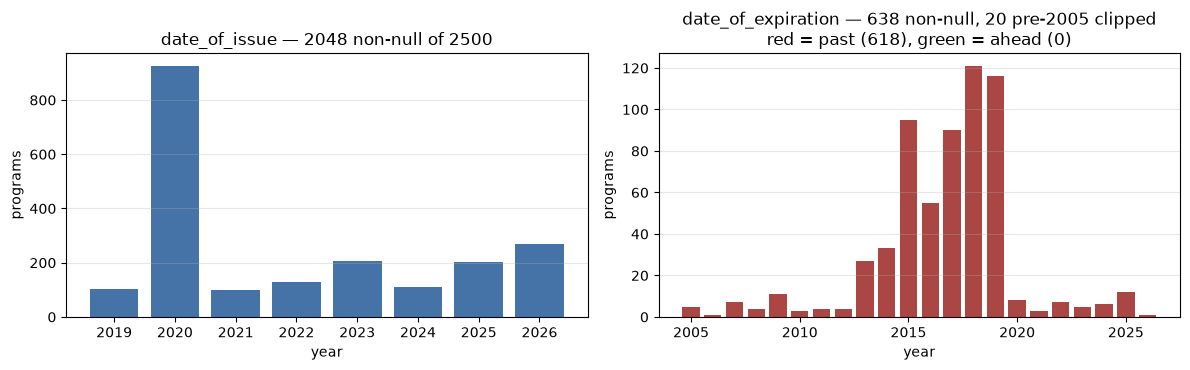

expiration still ahead of 2026-07-28: 0 of 638
latest expiration in export             : 2026-06-26 00:00:00+00:00


In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

iss = (
    fp_df.select(pl.col("date_of_issue").dt.year().alias("year")).drop_nulls()
         .group_by("year").len().sort("year")
)
axes[0].bar(iss["year"], iss["len"], color="#4573a7")
axes[0].set_title(f"date_of_issue — {iss['len'].sum()} non-null of {fp_df.height}")

# Split on `now`, not on year: the newest expiration in the export is
# 2026-06-26, so a >= current-year test would wrongly paint it as future.
LO = 2005
exp_all = fp_df.select(
    pl.col("date_of_expiration").alias("d"),
    pl.col("date_of_expiration").dt.year().alias("year"),
    (pl.col("date_of_expiration") >= now).alias("future"),
).drop_nulls()
clipped = exp_all.filter(pl.col("year") < LO).height
n_future = exp_all["future"].sum()
exp = exp_all.filter(pl.col("year") >= LO).group_by("year", "future").len().sort("year")

for future, color in ((False, "#aa4643"), (True, "#89a54e")):
    part = exp.filter(pl.col("future") == future)
    axes[1].bar(part["year"], part["len"], color=color)
axes[1].set_title(
    f"date_of_expiration — {exp_all.height} non-null, {clipped} pre-{LO} clipped\n"
    f"red = past ({exp_all.height - clipped - n_future}), green = ahead ({n_future})"
)

for ax in axes:
    ax.set_xlabel("year")
    ax.set_ylabel("programs")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"expiration still ahead of {now:%Y-%m-%d}: {n_future} of {exp_all.height}")
print(f"latest expiration in export             : {exp_all['d'].max()}")

In [ ]:
# Header inventory. Only 15 distinct strings, so list all of them instead of
# regex-bucketing blind, and state the denominator: 2274 of 2500 rows have no
# header text at all (empty <div> in the XML -> strip_html returns None).
with_header = fp_df.filter(pl.col("header").is_not_null())
print(f"header text present  : {with_header.height} / {fp_df.height}")
print(f"header empty (<div/>): {fp_df.height - with_header.height}")
print(f"distinct strings     : {with_header['header'].n_unique()}\n")

with pl.Config(fmt_str_lengths=120, tbl_rows=-1, tbl_hide_column_data_types=True):
    print(with_header["header"].value_counts().sort("count", descending=True))

## Lifecycle (header field)

`gsb:header` is the editor-written status note. Two things make a single
`lifecycle` column misleading:

* 2274 of 2500 programs have an empty header (`<div/>` in the XML), so the
  field says nothing at all about them.
* Where it is filled it states two independent facts — whether the *programme*
  still exists, and whether *applications* are being accepted. Every filled
  header is a negative or caveat note; none asserts plain "open for
  applications".

So classify on two axes instead of one.

In [ ]:
# Match on a normalised copy: the vocabulary contains akktiv, Antagstellung,
# Antragsstellung and merh.
norm = (
    pl.col("header").str.strip_chars().str.to_lowercase()
      .str.replace_all("akktiv", "aktiv")
      .str.replace_all(r"ant(r)?ag(s)?s?tellung", "antragstellung")
      .str.replace_all("merh", "mehr")
)

ENDED = r"ausgelaufen|abgelaufen|beendet|eingestellt"
DRAFT = r"beschreibung in (überarbeitung|erstellung)"
ACTIVE = r"programm aktiv"
LIMITED = r"ausschließlich anträge|in teilbereichen"
PAUSED = r"derzeit nicht"
CLOSED = r"nicht mehr möglich|einreichung nicht möglich"

fp_df = fp_df.with_columns(
    pl.when(norm.str.contains(ENDED)).then(pl.lit("ended"))
      .when(norm.str.contains(DRAFT)).then(pl.lit("description draft"))
      .when(norm.str.contains(ACTIVE)).then(pl.lit("active"))
      .otherwise(pl.lit("not stated"))
      .alias("programme"),
    pl.when(norm.str.contains(ENDED) | norm.str.contains(DRAFT)).then(pl.lit("not stated"))
      .when(norm.str.contains(LIMITED)).then(pl.lit("limited"))
      .when(norm.str.contains(PAUSED)).then(pl.lit("paused"))
      .when(norm.str.contains(CLOSED)).then(pl.lit("closed"))
      .otherwise(pl.lit("not stated"))
      .alias("intake"),
)

pct = (pl.col("len") / fp_df.height * 100).round(1).alias("pct")
for keys in (["programme"], ["intake"], ["programme", "intake"]):
    print(fp_df.group_by(keys).len().sort("len", descending=True).with_columns(pct))

# Guard: every filled header should match at least one pattern, else the
# vocabulary has grown and the patterns above need updating.
missed = fp_df.filter(
    pl.col("header").is_not_null()
    & ~norm.str.contains("|".join([ENDED, DRAFT, ACTIVE, LIMITED, PAUSED, CLOSED]))
)
print(f"filled headers matching no pattern: {missed.height}")

## Checks

In [14]:
# for row in df.iter_rows(named=True):
#     time.sleep(1)
#     res = requests.head(row["url"])
#     assert res.status_code == 302